In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import isautilities as isau
import xarray as xr
import sklearn as sk
from tqdm import tqdm

import pathlib
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISAUnits'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [2]:
def _populationGLM(session,regs=None,when='sleep.*#0',method='L2',scoring='average_precision',n_lags=1,subsample=10,n_delays=5,step=1,shuffle=1,verbose=False):
    # predict PFC population activity with region spike matrices just before (with history)

    R = fma.regions.regions(session,phases=when,states='sws',events='InfraSlowRhythm/infraslowaval')
    regs = R.ids if regs is None else np.asarray(regs)[np.isin(regs,R.ids)]

    # X: spike counts with history
    bin_x = 0.02
    fr_x = R.unitFiringRate(regs=regs,window=bin_x,when='sws')
    counts_x = fr_x[:,1:] * bin_x
    time_x = fr_x[:,0]
    if n_lags > 1: # add history
        n_times, n_units = counts_x.shape
        X = np.zeros((n_times-n_lags+1, n_units*n_lags))
        for t in range(n_lags-1,n_times):
            history = counts_x[t-n_lags+1:t+1][::-1] # reverse lag order
            X[t-n_lags+1] = history.flatten() # X[i]: [counts_x[i+n_lags-1], ..., counts_x[i]], so X[0] corresponds to time[n_lags-1]
        time_x = time_x[n_lags-1:]
    else:
        X = counts_x
    X_units = R.units(regs=regs)

    # subsample data (also reducing X autocorrelation)
    X = X[::subsample]
    time_x = time_x[::subsample]

    # y: future activity
    target = 'pfc'
    bin_y = 0.02
    spikes = R.spikes(regs=target)
    limits = (-bin_y/2, bin_y/2 + n_delays*bin_y)
    y, delays, _ = fma.analysis.PETH(spikes[:,0],time_x,groups=spikes[:,1],g_range=R.units(regs=target),limits=limits,bin=bin_y,step=step,fast=True) # (events, time, units)
    y = (y > 0).astype(float)
    n_targets = y.shape[-1]
    n_delays = len(delays)
    y_units = R.units(regs=target)

    # ISA
    isa = R.eventIntervals('slownr')
    nrem = R.eventIntervals('sws')
    is_isa = isau.isISA(time_x,isa,nrem)

    n_cv = 5
    #cv = sk.model_selection.TimeSeriesSplit(n_splits=n_cv,gap=50)
    cv = sk.model_selection.StratifiedKFold(n_splits=n_cv,shuffle=True,random_state=42)
    def cv_score(X,y):
        match method:
            case 'L2':
                model = sk.linear_model.LogisticRegression(C=0.00001,max_iter=5000) # L2 penalty
            case 'L2CV':
                inner_cv = sk.model_selection.StratifiedKFold(n_splits=n_cv,shuffle=True)
                model = sk.linear_model.LogisticRegressionCV(Cs=np.logspace(-4,1,5),l1_ratios=(0.,),
                            cv=inner_cv,scoring=scoring,max_iter=5000,refit=True,use_legacy_attributes=False)
            case 'SVM':
                model = sk.pipeline.make_pipeline(sk.preprocessing.StandardScaler(), sk.svm.SVC(kernel="rbf"))
        return sk.model_selection.cross_val_score(model,X,y,cv=cv,scoring=scoring)

    rng = np.random.default_rng()
    scores = np.full((2,shuffle+1,n_delays,n_targets,n_cv),np.nan)
    for a in range(2): # 0: ISA, 1: nISA
        verbose and print(f'ISA: {not a}')
        iterator = tqdm(enumerate(delays),total=n_delays,leave=False,desc="  delays:") if verbose else enumerate(delays)

        valid_isa = is_isa == a
        X_isa = X[valid_isa]
        for j, d in iterator:

            # train per neuron
            for i in range(n_targets):
                # exclude target from regressors
                if target in regs:
                    valid_clean = X_units != y_units[i]
                    X_isa_clean = X_isa[:,valid_clean]
                else:
                    X_isa_clean = X_isa

                # 1. observed
                y_isa = y[valid_isa,j,i]
                if y_isa.sum() < 5:
                    continue
                scores[a,0,j,i] = cv_score(X_isa_clean,y_isa)

                # 2. surrogate
                for k in range(shuffle):
                    rng.shuffle(y_isa)
                    scores[a,k+1,j,i] = cv_score(X_isa_clean,y_isa)

    scores = xr.DataArray(scores,dims=['isa','shuffle','t','i','cv'],coords={'isa': [True,False], 'shuffle': [False]+[True]*shuffle, 't': delays, 'rat': int(R.rat)})
    match shuffle:
        case 0: gain = scores.sel(shuffle=False).mean(dim='cv') * np.nan
        case 1: gain = scores.sel(shuffle=False).mean(dim='cv') / scores.sel(shuffle=True).mean(dim='cv')
        case _: gain = scores.sel(shuffle=False).mean(dim='cv') / scores.sel(shuffle=True).mean(dim='cv').mean(dim='shuffle')
    peak_t = gain.t[gain.argmax(dim='t')] if shuffle > 0 else scores.t[scores.argmax(dim='t')]

    return scores, gain, peak_t

In [3]:
 # test on one session
session = fma.data.readBatchFile(batch_file)[0][27]
print(session)
regs = ['hpc','nr','pfc'] # ,['hpc','nr']
keys = ['hpc','nr','pfc'] # ,'hpc+nr'
scores = {}; gain = {}; peak_t = {}
for i, r in enumerate(regs):
    scores[keys[i]], gain[keys[i]], peak_t[keys[i]] = _populationGLM(session,regs=r,n_delays=4,step=4,shuffle=50,verbose=True)
    print()

/mnt/hubel-data-140/karadoc/Rat004_20240316/Rat004_20240316.xml
ISA: True


ISA: False



ISA: True


ISA: False



ISA: True


ISA: False


Failed to reload module '_collections_abc' from file '/usr/lib/python3.12/_collections_abc.py'
Traceback (most recent call last):
  File "/home/pietro/uvEnvs/fmat_edit12/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "/home/pietro/uvEnvs/fmat_edit12/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 584, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/importlib/__init__.py", line 111, in reload
    raise ImportError(f"module {name} not in sys.modules", name=name)
ImportError: module collections.abc not in sys.modules
[autoreload of _collections_abc failed: Traceback (most recent call last):
  File "/home/pietro/uvEnvs/fmat_edit12/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "/home/pietro/uvEnvs/fmat_edit12/lib/python3.12/site-packages/IPython/

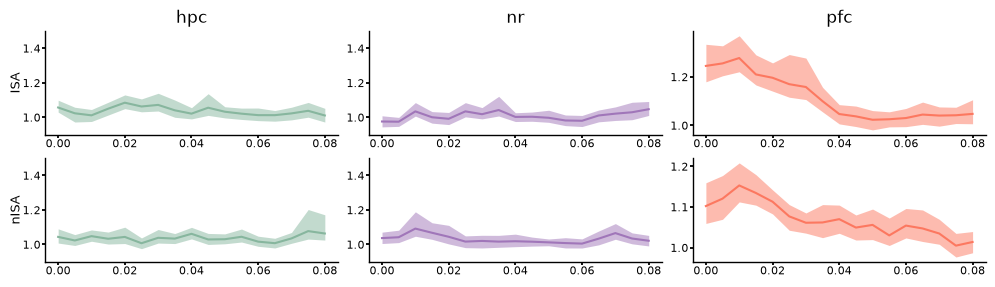

In [4]:
# gain, bin y: 20 ms, 50 shuffles
fig, ax = fma.plotting.makeFigure(size=(25,7),n=(2,len(scores)))
ax = np.array(ax,ndmin=2)
for i, k in enumerate(keys):
    for j, a in enumerate([True,False]):
        fma.plotting.semPlot(gain[k].t,gain[k].sel(isa=a).T,color=isau.paperColors(k),ax=ax[j,i])
    ax[0,i].set(title=keys[i])
ax[0,0].set(ylabel='ISA'), ax[1,0].set(ylabel='nISA'), fma.plotting.setProp(ax[:,:-1],ylim=(0.9,1.5));

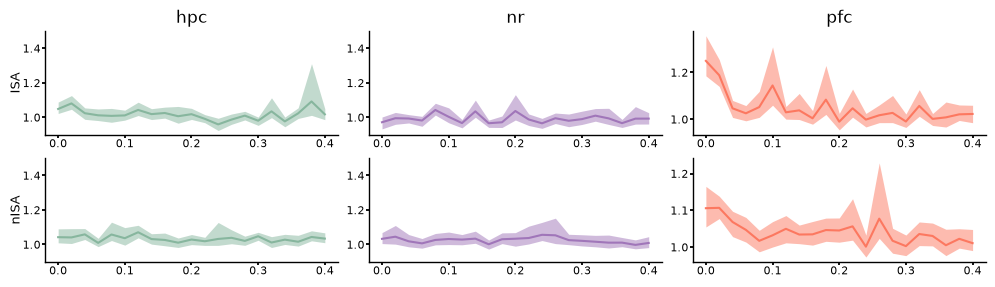

In [4]:
# gain, bin y: 20 ms, 100 shuffles
fig, ax = fma.plotting.makeFigure(size=(25,7),n=(2,len(scores)))
ax = np.array(ax,ndmin=2)
for i, k in enumerate(keys):
    for j, a in enumerate([True,False]):
        fma.plotting.semPlot(gain[k].t,gain[k].sel(isa=a).T,color=isau.paperColors(k),ax=ax[j,i])
    ax[0,i].set(title=keys[i])
ax[0,0].set(ylabel='ISA'), ax[1,0].set(ylabel='nISA'), fma.plotting.setProp(ax[:,:-1],ylim=(0.9,1.5));

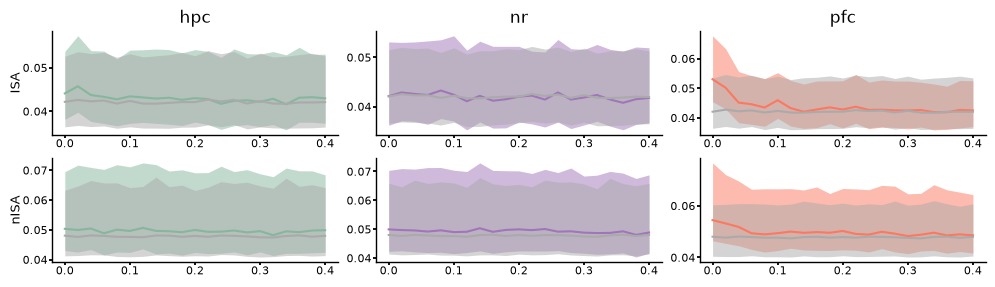

In [12]:
# scores, bin y: 20 ms, 100 shuffles
fig, ax = fma.plotting.makeFigure(size=(25,7),n=(2,len(scores)))
for i, k in enumerate(keys):
    for j, a in enumerate([True,False]):
        fma.plotting.semPlot(scores[k].t,scores[k].sel(isa=a,shuffle=False).mean(dim='cv').T,color=isau.paperColors(k),ax=ax[j,i])
        fma.plotting.semPlot(scores[k].t,scores[k].sel(isa=a,shuffle=True).mean(dim='cv').mean(dim='shuffle').T,color=isau.paperColors('shuffle'),ax=ax[j,i])
    ax[0,i].set(title=keys[i])
ax[0,0].set(ylabel='ISA'), ax[1,0].set(ylabel='nISA');

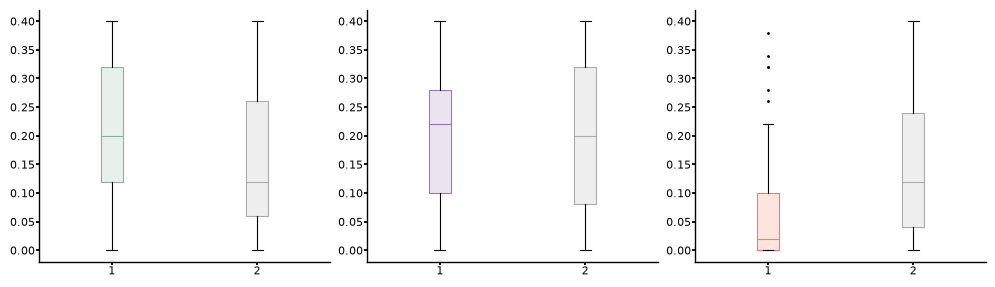

In [28]:
# peak-gain time
fig, ax = fma.plotting.makeFigure(size=(25,7),n=(1,len(scores)))
for i, k in enumerate(keys):
    fma.plotting.boxPlot(peak_t[k],ax=ax[i],color=isau.paperColors((k,'shuffle')))